In [3]:
import random

def generate_gc_private_keys(message_length, key_length=3):
    """
    Generates Lamport-style private keys for the Gottesman-Chuang protocol.
    Creates a unique key for every possible bit (0 or 1) at every position.
    """
    private_keys = {}
    
    # Loop through each position in the message (e.g., Position 1, Position 2...)
    for pos in range(1, message_length + 1):
        
        # Generate the secret key used if the bit at this position is '0'
        k_0 = ''.join(random.choice(['0', '1']) for _ in range(key_length))
        private_keys[(pos, 0)] = k_0
        
        # Generate the secret key used if the bit at this position is '1'
        k_1 = ''.join(random.choice(['0', '1']) for _ in range(key_length))
        private_keys[(pos, 1)] = k_1
        
    return private_keys

# Let's set up our project for a 2-bit message. 
# We will use 3-bit strings for the private keys to keep the quantum circuit manageable.
MESSAGE_LENGTH = 2
KEY_LENGTH = 3

# Generate Alice's master set of private keys
alice_private_keys = generate_gc_private_keys(MESSAGE_LENGTH, KEY_LENGTH)

print("--- STEP 1: GOTTESMAN-CHUANG PRIVATE KEY GENERATION ---")
print(f"Preparing to sign a {MESSAGE_LENGTH}-bit message.\n")

for (position, bit_value), key_string in alice_private_keys.items():
    print(f"Position {position}, if message bit is '{bit_value}' -> Private Key: {key_string}")

print("\nStatus: Alice has generated these keys and locked them on her local hard drive.")

--- STEP 1: GOTTESMAN-CHUANG PRIVATE KEY GENERATION ---
Preparing to sign a 2-bit message.

Position 1, if message bit is '0' -> Private Key: 001
Position 1, if message bit is '1' -> Private Key: 000
Position 2, if message bit is '0' -> Private Key: 011
Position 2, if message bit is '1' -> Private Key: 101

Status: Alice has generated these keys and locked them on her local hard drive.


--- STEP 2: THE QUANTUM ONE-WAY FUNCTION ---
Applying QOWF for classical key: 101


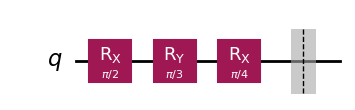

In [ ]:
import numpy as np
from qiskit import QuantumCircuit

def apply_qowf(qc, qubit_index, classical_key):
    """
    The Quantum One-Way Function. 
    Takes a classical bit string and applies a unique sequence of 
    quantum rotations to a specific qubit to create the Public Key.
    """
    # We define specific, unique angles for each step of the password.
    # We use fractions of pi to create complex superpositions.
    angles =[np.pi/2, np.pi/3, np.pi/4, np.pi/5, np.pi/6]
    
    for i in range(len(classical_key)):
        bit = classical_key[i]
        angle = angles[i % len(angles)] # Pick the angle for this step
        
        if bit == '0':
            # If classical bit is 0, apply Ry gate (Y-axis rotation)
            qc.ry(angle, qubit_index)
        elif bit == '1':
            # If classical bit is 1, apply Rx gate (X-axis rotation)
            qc.rx(angle, qubit_index)
            
    # We add a barrier just to make the circuit diagram look clean later
    qc.barrier(qubit_index)

# ==========================================
# LET'S TEST IT OUT TO SEE HOW IT LOOKS
# ==========================================

# Create a tiny 1-qubit circuit just for this test
test_circuit = QuantumCircuit(1)

# Let's take the very first private key Alice generated in Step 1
# (We will use a hardcoded "101" just for this visual test)
test_key = "101" 

print(f"--- STEP 2: THE QUANTUM ONE-WAY FUNCTION ---")
print(f"Applying QOWF for classical key: {test_key}")

# Run the function on Qubit 0
apply_qowf(test_circuit, 0, test_key)

# Draw the circuit so you can see what Alice's computer actually did
display(test_circuit.draw('mpl'))

--- STEP 3: SIGNING AND VERIFICATION ---
Alice is transmitting the message: '10'

Alice's revealed Classical Signature:
  For Bit 1 ('1'): 000
  For Bit 2 ('0'): 011

-> Alice sends Message + Signature to Bob over the normal internet.

Bob receives the data. Building verification circuits...

Circuit Diagram for Verifying Bit 1:


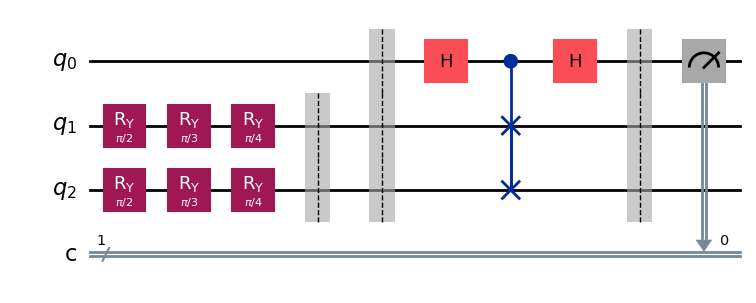


Executing the Swap Tests on the AerSimulator...
Results for Bit 1: {'0': 1024}
  [PASS] 100% Measurement of '0'. Signature for Bit 1 is AUTHENTIC.
Results for Bit 2: {'0': 1024}
  [PASS] 100% Measurement of '0'. Signature for Bit 2 is AUTHENTIC.


In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# ==========================================
# 1. ALICE SIGNS THE MESSAGE
# ==========================================
message = "10"
print(f"--- STEP 3: SIGNING AND VERIFICATION ---")
print(f"Alice is transmitting the message: '{message}'\n")

# Alice retrieves the correct private keys from her hard drive (from Step 1)
# Bit 1 is '1', so she needs the key for (Position 1, Value 1)
signature_part_1 = alice_private_keys[(1, 1)] 

# Bit 2 is '0', so she needs the key for (Position 2, Value 0)
signature_part_2 = alice_private_keys[(2, 0)] 

alice_signature =[signature_part_1, signature_part_2]

print(f"Alice's revealed Classical Signature:")
print(f"  For Bit 1 ('1'): {signature_part_1}")
print(f"  For Bit 2 ('0'): {signature_part_2}\n")
print(f"-> Alice sends Message + Signature to Bob over the normal internet.\n")

# ==========================================
# 2. BOB VERIFIES THE SIGNATURE (CIRCUIT CREATION)
# ==========================================
print("Bob receives the data. Building verification circuits...")

verification_circuits =[]

# Loop through each bit of the message to build a Swap Test for it
for i in range(len(message)):
    pos = i + 1          # Position (1 or 2)
    bit_val = int(message[i]) # The actual bit value (0 or 1)
    revealed_key = alice_signature[i]
    
    # Initialize a 3-qubit circuit with 1 classical bit for measurement
    qc = QuantumCircuit(3, 1, name=f"Verify_Bit_{pos}")
    
    # --- PHASE A: Bob's Quantum Memory (The Public Key) ---
    # Bob retrieves the Public Key Alice gave him weeks ago. 
    # To simulate this, we use the TRUE key from Step 1 on Qubit 1.
    true_key = alice_private_keys[(pos, bit_val)]
    apply_qowf(qc, qubit_index=1, classical_key=true_key)
    
    # --- PHASE B: Bob's Local Generation ---
    # Bob takes the signature Alice just revealed and runs it through the QOWF
    # on his own local machine (Qubit 2).
    apply_qowf(qc, qubit_index=2, classical_key=revealed_key)
    
    qc.barrier() # Visual separator
    
    # --- PHASE C: THE SWAP TEST ---
    # 1. Hadamard on Ancilla (Qubit 0)
    qc.h(0)
    # 2. Controlled-SWAP (Fredkin) using Qubit 0 as control, Q1 and Q2 as targets
    qc.cswap(0, 1, 2)
    # 3. Hadamard on Ancilla
    qc.h(0)
    
    qc.barrier() # Visual separator
    
    # --- PHASE D: MEASUREMENT ---
    # Measure ONLY the Ancilla qubit into the classical bit
    qc.measure(0, 0)
    
    verification_circuits.append(qc)

# Draw the circuit for the first bit so we can inspect the exact gate layout
print("\nCircuit Diagram for Verifying Bit 1:")
display(verification_circuits[0].draw('mpl'))

# ==========================================
# 3. EXECUTE THE SIMULATION
# ==========================================
print("\nExecuting the Swap Tests on the AerSimulator...")

simulator = AerSimulator()
shots = 1024

results_data =[]

for idx, qc in enumerate(verification_circuits):
    # Transpile the circuit for the simulator
    compiled_circuit = transpile(qc, simulator)
    
    # Run the job
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts(compiled_circuit)
    
    results_data.append(counts)
    
    print(f"Results for Bit {idx + 1}: {counts}")
    
    # Cryptographic Logic Check:
    if '1' in counts:
        print(f"  [ALARM] Measurement of '1' detected! Signature for Bit {idx + 1} is a FORGERY.")
    else:
        print(f"  [PASS] 100% Measurement of '0'. Signature for Bit {idx + 1} is AUTHENTIC.")

--- STEP 4: THE HACKER SCENARIO (EVE) ---
Eve intercepts the message and changes it to: '11'

Eve's Forged Classical Signature:
  For Bit 1 ('1'): 000 (Stolen from Alice)
  For Bit 2 ('1'): 001 (Eve's random guess)

-> Eve sends the Forged Message + Forged Signature to Bob.

Bob receives the data. Building verification circuits...

Executing the Swap Tests on the AerSimulator...
Results for Bit 1: {'0': 1024}
  [PASS] 100% Measurement of '0'. Signature for Bit 1 appears Authentic.
Results for Bit 2: {'1': 254, '0': 770}
  [ALARM] Measurement of '1' detected! Signature for Bit 2 is a FORGERY. Transaction Rejected!

Plotting the mathematical proof of the forgery:


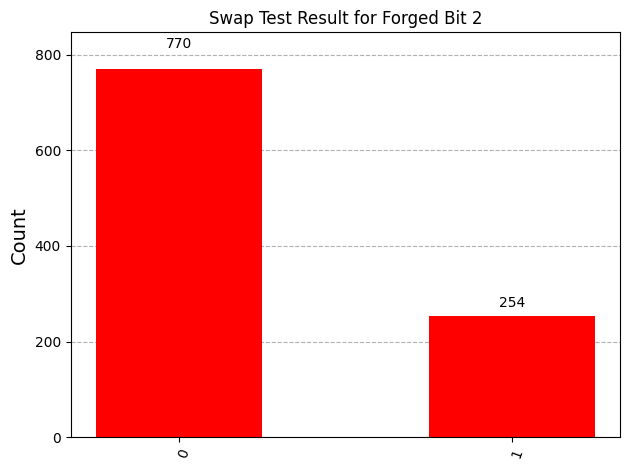

In [8]:
# ==========================================
# 1. EVE FORGES THE MESSAGE
# ==========================================
print(f"--- STEP 4: THE HACKER SCENARIO (EVE) ---")

# Eve intercepts and changes the message
forged_message = "11" 
print(f"Eve intercepts the message and changes it to: '{forged_message}'\n")

# Eve needs to build a forged signature.
# For Bit 1 ('1'): Eve just copies Alice's true revealed key.
eve_sig_part_1 = alice_private_keys[(1, 1)] 

# For Bit 2 ('1'): Eve needs the key for (Pos 2, Val 1), but doesn't have it.
# Eve makes a random guess.
import random
eve_guess = ''.join(random.choice(['0', '1']) for _ in range(KEY_LENGTH))
eve_sig_part_2 = eve_guess 

forged_signature = [eve_sig_part_1, eve_sig_part_2]

print(f"Eve's Forged Classical Signature:")
print(f"  For Bit 1 ('1'): {eve_sig_part_1} (Stolen from Alice)")
print(f"  For Bit 2 ('1'): {eve_sig_part_2} (Eve's random guess)\n")
print(f"-> Eve sends the Forged Message + Forged Signature to Bob.\n")


# ==========================================
# 2. BOB VERIFIES THE FORGED SIGNATURE
# ==========================================
print("Bob receives the data. Building verification circuits...")

hacker_verification_circuits =[]

for i in range(len(forged_message)):
    pos = i + 1          
    bit_val = int(forged_message[i]) 
    received_key = forged_signature[i]
    
    qc_hacker = QuantumCircuit(3, 1, name=f"Hacker_Verify_Bit_{pos}")
    
    # PHASE A: Bob's Quantum Memory (The TRUE Public Key Alice sent weeks ago)
    # Bob loads the true key for the bit value he received.
    true_key = alice_private_keys[(pos, bit_val)]
    apply_qowf(qc_hacker, qubit_index=1, classical_key=true_key)
    
    # PHASE B: Bob's Local Generation (Using Eve's forged key)
    apply_qowf(qc_hacker, qubit_index=2, classical_key=received_key)
    
    qc_hacker.barrier()
    
    # PHASE C: THE SWAP TEST
    qc_hacker.h(0)
    qc_hacker.cswap(0, 1, 2)
    qc_hacker.h(0)
    
    qc_hacker.barrier()
    
    # PHASE D: MEASUREMENT
    qc_hacker.measure(0, 0)
    
    hacker_verification_circuits.append(qc_hacker)

# ==========================================
# 3. EXECUTE THE SIMULATION (CATCHING EVE)
# ==========================================
print("\nExecuting the Swap Tests on the AerSimulator...")

results_data_hacker =[]

for idx, qc in enumerate(hacker_verification_circuits):
    compiled_circuit = transpile(qc, simulator)
    job = simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    counts = result.get_counts(compiled_circuit)
    
    results_data_hacker.append(counts)
    
    print(f"Results for Bit {idx + 1}: {counts}")
    
    # The absolute cryptographic rule:
    if '1' in counts:
        print(f"  [ALARM] Measurement of '1' detected! Signature for Bit {idx + 1} is a FORGERY. Transaction Rejected!")
    else:
        print(f"  [PASS] 100% Measurement of '0'. Signature for Bit {idx + 1} appears Authentic.")

# Let's visualize the failure
print("\nPlotting the mathematical proof of the forgery:")
display(plot_histogram(results_data_hacker[1], title="Swap Test Result for Forged Bit 2", color='red'))

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

print("--- STEP 5: REAL HARDWARE EXECUTION ---")

# ==========================================
# 1. CONNECT TO THE IBM QUANTUM CLOUD
# ==========================================
# IMPORTANT: Replace "YOUR_API_TOKEN_HERE" with your actual token!
# If you already saved your account previously, you can just use QiskitRuntimeService()
try:
    service = QiskitRuntimeService(channel="ibm_quantum", token="YOUR_API_TOKEN_HERE")
except Exception as e:
    print("Already authenticated or token error. Attempting default load...")
    service = QiskitRuntimeService()

# Find the least busy real quantum computer that has at least 3 qubits
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
print(f"Success! Connected to real IBM hardware: {backend.name}")

# ==========================================
# 2. PREPARE THE "HONEST ALICE" CIRCUIT
# ==========================================
# We will use the very first verification circuit from Step 3 (Bit 1).
# We know this circuit is mathematically perfect and should yield 100% '0's.
honest_qc = verification_circuits[0]

# Real hardware cannot read abstract gates. We must "transpile" the circuit.
# This maps our logical qubits to the specific physical layout of the chosen IBM chip.
print(f"Transpiling the circuit for {backend.name}...")
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pass_manager.run(honest_qc)

# ==========================================
# 3. SEND TO THE QUANTUM COMPUTER
# ==========================================
print(f"Submitting job to {backend.name}. You are now in the queue...")
print("Please wait. This may take a while depending on global traffic.")

# We use the SamplerV2 primitive to execute the job on the hardware
sampler = Sampler(backend)
shots = 1024
job = sampler.run([isa_circuit], shots=shots)

# This line pauses Python until IBM physically finishes running your job
result = job.result()

# ==========================================
# 4. EXTRACT DATA & CALCULATE FALSE NEGATIVES
# ==========================================
print("\nJob Complete! Extracting physical data...\n")

# Get the counts from the classical register (usually named 'c' or 'meas')
# We access the first (and only) circuit result
pub_result = result[0]
counts = pub_result.data.c.get_counts() # If it throws an error here, check your classical register name!

print(f"Raw Hardware Counts: {counts}")

# Extract the number of '0's and '1's
count_0 = counts.get('0', 0)
count_1 = counts.get('1', 0)

# Calculate the critical metrics
false_negative_rate = (count_1 / shots) * 100
reliability_rate = (count_0 / shots) * 100

print("\n==================================================")
print("FINAL SCIENTIFIC METRICS (THE CONCLUSION)")
print("==================================================")
print(f"Hardware Used:        {backend.name}")
print(f"Total Shots:          {shots}")
print(f"Valid Passes ('0'):   {count_0}")
print(f"False Alarms ('1'):   {count_1}")
print("--------------------------------------------------")
print(f"RELIABILITY RATE:     {reliability_rate:.2f}%")
print(f"FALSE NEGATIVE RATE:  {false_negative_rate:.2f}%")
print("==================================================\n")

if count_1 > 0:
    print("CONCLUSION: Hardware noise caused the Swap Test to fail.")
    print("Even though Alice was honest, Bob's computer falsely detected a forgery.")
    print("This proves that current NISQ hardware is not yet ready for commercial Quantum Digital Signatures.")

# Visualize the noisy reality
display(plot_histogram(counts, title=f"Real Hardware Noise on {backend.name} (Honest Alice)", color='blue'))